sat
[x_SCL_02 = 3,
 dr_SCL_00 = 2,
 dr_SCL_05 = 2,
 l_VCC_01 = -1,
 l_VCC_00 = 0,
 dr_VCC_00 = 3,
 x_VCC_02 = 2,
 l_VCC_04 = -7,
 l_SCL_02 = 9,
 l_VCC_02 = -1,
 l_SCL_03 = 1,
 x_SCL_01 = 1,
 x_VCC_04 = 3,
 l_SCL_04 = -1,
 x_SCL_03 = 12,
 l_SCL_01 = -2,
 y_SCL_03 = 17,
 y_VCC_04 = 9,
 x_VCC_01 = 1,
 x_SCL_04 = 13,
 y_SCL_02 = 8,
 y_SCL_01 = 8,
 x_VCC_03 = 3,
 y_SCL_04 = 17,
 y_VCC_03 = 9,
 y_VCC_01 = 10,
 y_VCC_02 = 9,
 l_SCL_00 = 0,
 l_VCC_03 = 0,
 y_SCL_00 = 8,
 y_VCC_00 = 10,
 y_SCL_05 = 16,
 dr_SCL_03 = 2,
 dr_VCC_02 = 2,
 dr_VCC_01 = 3,
 dr_SCL_01 = 2,
 dr_VCC_05 = 0,
 dr_SCL_04 = 3,
 x_SCL_00 = 1,
 dr_VCC_03 = 1,
 dr_VCC_04 = 1,
 x_SCL_05 = 14,
 x_VCC_05 = 10,
 dr_SCL_02 = 1,
 y_VCC_05 = 16,
 x_VCC_00 = 1]


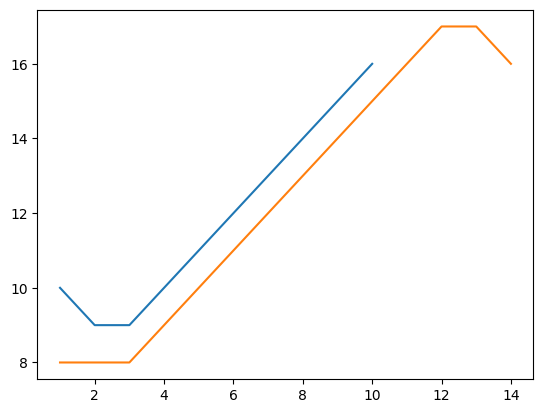

In [13]:
from matplotlib import pyplot as plt
import numpy as np
import time

import z3
z3.set_param("parallel.enable", "true")
z3.set_param("smt.arith.random_initial_value", True)
z3.set_param("memory_max_size", 8*4096)   # Setze das maximale Speicherlimit (in MB)
z3.set_param("smt.threads", 16)         # Anzahl der SMT-Solver-Threads
z3.set_param("sat.threads", 16)         # Anzahl der SAT-Solver-Threads
z3.set_param("parallel.threads.max", 16)  # Maximale Anzahl der Threads
z3.set_param("smt.random_seed", 42)     # Setze einen Seed, um die Zufälligkeit zu steuern
#z3.set_param("verbose", 10)


def bend_45(l, dr0, dr1):
    #limits = z3.And(l != 0)
    model = dr1 == z3.If(l >= 0, z3.If(l == 0, dr0, dr0 + 1), dr0 - 1)
    return model
    #return z3.And(limits, model)

def segment(x0,y0, x1, y1, dr, l):
    labs = z3.If(l < 0, -l, l)
    model = z3.If(dr==0, z3.And(x1 == x0, y1 == y0 + labs), \
            z3.If(dr==1, z3.And(x1 == x0 + labs, y1 == y0 + labs), \
            z3.If(dr==2, z3.And(x1 == x0 + labs, y1 == y0), \
            z3.If(dr==3, z3.And(x1 == x0 + labs, y1 == y0 - labs), \
            z3.If(dr==4, z3.And(x1 == x0, y1 == y0 - labs), \
            z3.If(dr==5, z3.And(x1 == x0 - labs, y1 == y0 - labs), \
            z3.If(dr==6, z3.And(x1 == x0 - labs, y1 == y0), \
            z3.If(dr==7, z3.And(x1 == x0 - labs, y1 == y0 + labs), \
            False))))))))
    return model

def check_collision(xa, ya, dra, la, xb, yb, drb, lb):
    lacabs = z3.If(la >= 0, la, -la)
    lbcabs = z3.If(lb >= 0, lb, -lb)
    return check_collision_core(xa, ya, dra, lacabs, xb, yb, drb, lbcabs)

def check_collision_core(xa, ya, dra, la, xb, yb, drb, lb):
    xd = xb - xa
    yd = yb - ya
    drd = (drb - dra) 
    xt4 = z3.If((dra >> 2) & 1 == 1, -xd, xd)
    yt4 = z3.If((dra >> 2) & 1 == 1, -yd, yd)
    xt2 = z3.If((dra >> 1) & 1 == 1, -yt4, xt4)
    yt2 = z3.If((dra >> 1) & 1 == 1, xt4, yt4)
    xt = z3.If(dra & 1 == 1, xt2 - yt2, xt2)
    yt = z3.If(dra & 1 == 1, yt2 + xt2, yt2)
    lat = z3.If(dra & 1 == 1, 2 * la, la)
    lbt = z3.If(dra & 1 == 1, 2 * lb, lb)
    
    collision = z3.If(drd==0, z3.If(xt == 0, z3.If(yt <= 0, lbt >= -yt, yt <= lat), False), \
           z3.If(drd==1, z3.If(yt - xt >= 0, z3.If(yt - xt <= lat, z3.If(xt <= 0, lbt >= -xt , False), False), False), \
           z3.If(drd==2, z3.If(yt >= 0, z3.If(yt <= lat, z3.If(xt <= 0, lbt >= -xt , False), False), False), \
           z3.If(drd==3, z3.If(yt + xt >= 0, z3.If(yt + xt <= lat, z3.If(xt <= 0, lbt >= -xt , False), False), False), \
           z3.If(drd==4, z3.If(xt == 0, z3.If(yt <= 0, False, yt <= lat + lbt), False), \
           z3.If(drd==5, z3.If(yt - xt >= 0, z3.If(yt - xt <= lat, z3.If(xt >= 0, lbt >= xt , False), False), False), \
           z3.If(drd==6, z3.If(yt >= 0, z3.If(yt <= lat, z3.If(xt >= 0, lbt >= xt , False), False), False), \
           z3.If(drd==7, z3.If(yt + xt >= 0, z3.If(yt + xt <= lat, z3.If(xt >= 0, lbt >= xt , False), False), False), \
           False))))))))
    return z3.Not(collision)

def z3extract(z3model, z3vars):
    if isinstance(z3vars, list):
        return [z3model[e].as_long() for e in z3vars]
    else:
        return z3model[z3vars].as_long()


def declare_trace(name, nbr_segments):
    return [[z3.Int(f"x_{name}_{s:02}"),
              z3.Int(f"y_{name}_{s:02}"),
              z3.BitVec(f"dr_{name}_{s:02}", 3),
              z3.Int(f"l_{name}_{s:02}")] for s in range(nbr_segments)]

def constraint_trace_endpoints(trace, start, end):
    return z3.And(trace[0][0] == start[0], trace[0][1] == start[1], trace[-1][0] == end[0], trace[-1][1] == end[1])

def constraint_x_upper_limit(traces, x_max):
    return z3.And([point[0] <= x_max for trace in traces for point in trace])

def constraint_x_lower_limit(traces, x_min):
    return z3.And([point[0] >= x_min for trace in traces for point in trace])

def constraint_y_upper_limit(traces, y_max):
    return z3.And([point[1] <= y_max for trace in traces for point in trace])

def constraint_y_lower_limit(traces, y_min):
    return z3.And([point[1] >= y_min for trace in traces for point in trace])

def constraint_coord_limit(traces, x_min, y_min, x_max, y_max):
    return z3.And(constraint_x_lower_limit(traces, x_min), \
                  constraint_y_lower_limit(traces, y_min), \
                  constraint_x_upper_limit(traces, x_max), \
                  constraint_y_upper_limit(traces, y_max))


def create_all_segment_constraints(traces):
     return [segment(trace[i][0], trace[i][1], trace[i+1][0], trace[i+1][1], trace[i][2], trace[i][3]) for trace in traces for i in range(len(trace)-1)]
   
def create_all_bend_constraints(traces):
    return [bend_45(trace[i][3], trace[i][2], trace[i+1][2]) for trace in traces for i in range(len(trace)-1)]

def create_all_collision_constraints(traces):
    return [check_collision(traces[ita][isa][0],traces[ita][isa][1],traces[ita][isa][2],traces[ita][isa][3],
                            traces[itb][isb][0],traces[itb][isb][1],traces[itb][isb][2],traces[itb][isb][3]) \
        for ita in range(len(traces)) for itb in range(ita,len(traces)) for isa in range(len(traces[ita])-1) for isb in range(len(traces[itb])-1) if ita != itb]




traces = [declare_trace("VCC", 6),
          declare_trace("SCL", 6),
         # declare_trace("SDA", 8),
         # declare_trace("MFP", 6),
         # declare_trace("GND", 6),
         ]


segment_constraints = create_all_segment_constraints(traces)
bend_constraints = create_all_bend_constraints(traces)
collision_constraints = create_all_collision_constraints(traces)

endpoint_constraints = [constraint_trace_endpoints(traces[0], [1, 10], [10, 16]),
                        constraint_trace_endpoints(traces[1], [1, 8], [14, 16]),
                       # constraint_trace_endpoints(traces[2], [1, 6], [12, 16]),
                       # constraint_trace_endpoints(traces[3], [1, 4], [16, 16]),
                       # constraint_trace_endpoints(traces[4], [1, 2], [18, 16]),
                       ]

coord_limit_constraints = constraint_coord_limit(traces, 0, 0, 22, 25) 
    
s = z3.Solver()
s.add(*bend_constraints,*segment_constraints,*endpoint_constraints, *collision_constraints, coord_limit_constraints)

print(s.check())
m = s.model()
print(m)

traces_plot = [z3extract(m, [segment[d] for segment in trace]) for trace in traces for d in [0,1]]


from matplotlib import pyplot as plt

#plt.plot(xapv, yapv, xbpv, ybpv)
plt.plot(*traces_plot)

plt.show()

In [94]:
# tests

s = z3.Solver()
s.add(check_collision(0,0,0,0,0,0,0,0))
print(s.check())
s = z3.Solver()
s.add(check_collision(0,0,0,4,1,1,7,2))
print(s.check())




unsat
unsat


In [4]:
sat
[dr_001_05 = 0,
 dr_001_03 = 0,
 dr_002_02 = 7,
 y_001_00 = 4,
 dr_001_04 = 1,
 dr_001_01 = 2,
 dr_000_01 = 4,
 dr_003_04 = 2,
 y_000_00 = 2,
 dr_001_02 = 1,
 x_000_02 = 4,
 dr_000_03 = 2,
 y_002_05 = 12,
 y_000_05 = 12,
 x_002_00 = 1,
 y_003_05 = 12,
 dr_003_01 = 5,
 dr_003_05 = 1,
 dr_003_03 = 3,
 x_000_00 = 1,
 y_001_05 = 12,
 y_002_00 = 6,
 x_002_05 = 15,
 dr_000_02 = 3,
 dr_003_02 = 4,
 dr_002_01 = 6,
 x_001_04 = 17,
 dr_002_03 = 0,
 x_000_05 = 19,
 dr_000_04 = 1,
 dr_000_05 = 0,
 dr_002_04 = 1,
 dr_002_05 = 2,
 x_003_00 = 1,
 x_001_00 = 1,
 y_003_00 = 8,
 x_001_05 = 17,
 x_003_05 = 13,
 dr_001_00 = 3,
 l_003_00 = 9,
 y_002_03 = 11,
 x_000_01 = 1,
 l_000_03 = -1,
 l_003_04 = -15,
 l_000_04 = -21,
 l_001_04 = -4,
 x_001_02 = 16,
 y_001_01 = 4,
 l_002_04 = 32,
 l_000_00 = 9,
 l_000_02 = -14,
 y_002_01 = 6,
 l_001_02 = -2,
 x_003_04 = -2,
 l_003_02 = -1,
 dr_003_00 = 4,
 x_001_01 = 15,
 y_003_02 = -2,
 l_002_00 = 16,
 x_001_03 = 16,
 x_003_03 = -7,
 y_001_04 = 8,
 x_002_02 = -18,
 y_001_03 = 7,
 y_000_02 = -10,
 y_002_02 = 9,
 x_002_03 = -18,
 dr_000_00 = 3,
 x_000_03 = 18,
 y_000_04 = -9,
 y_001_02 = 5,
 y_000_01 = -7,
 x_000_04 = 19,
 l_003_01 = -1,
 x_003_02 = -8,
 y_003_04 = -3,
 y_002_04 = 12,
 l_001_03 = 1,
 l_002_02 = 2,
 l_003_03 = -5,
 x_003_01 = -8,
 x_002_01 = -15,
 y_003_01 = -1,
 l_000_01 = -3,
 y_000_03 = -10,
 l_001_01 = -1,
 l_002_01 = 3,
 l_002_03 = 1,
 dr_002_00 = 5,
 y_003_03 = -3,
 l_001_00 = -14,
 x_002_04 = -17]

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (346671386.py, line 2)

In [ ]:

lv = [3, 3, 3, 3,3,3,4,4,4,4,4,4,-4,-4,-4,-4,-4,-3,-3,-3,-3]
p0 = (0,0)
p = p0
pltv = [p0]
dr0 = 0
dr = dr0
for e in lv:
    dr = (dr + np.sign(e)) & 7
    l = np.abs(e)
    slct = [(p[0], p[1] + l),
            (p[0] + l, p[1] + l),
            (p[0] + l, p[1]),
            (p[0] + l, p[1] - l),
            (p[0], p[1] - l),
            (p[0] - l, p[1] - l),
            (p[0] - l, p[1]),
            (p[0] - l, p[1] + l)]
    p = slct[dr]
    pltv.append(p)

print(pltv)
pltv2 = [[e[0] for e in pltv], [e[1] for e in pltv]]
plt.plot(pltv2[0], pltv2[1])

plt.show()



In [1]:
xa = z3.Int("xa")
ya = z3.Int("ya")
dra = z3.Int("dra")
la = z3.Int("la")
xb = z3.Int("xb")
yb = z3.Int("yb")
drb = z3.Int("drb")
lb = z3.Int("lb")

xb = 1
yb = 3
drb = 4
lb = 7

check_collision(xa, ya, dra, la, xb, yb, drb, lb)
s = z3.Solver()
s.add(check_collision(xa, ya, dra, la, xb, yb, drb, lb))
print(s.check())
m = s.model()
print(m)

NameError: name 'z3' is not defined

In [ ]:
xap = [z3.Int("xa0"), z3.Int("xa1"), z3.Int("xa2"), z3.Int("xa3"), z3.Int("xa4"), z3.Int("xa5")]
yap = [z3.Int("ya0"), z3.Int("ya1"), z3.Int("ya2"), z3.Int("ya3"), z3.Int("ya4"), z3.Int("ya5")]
drap = [z3.Int("drap0"), z3.Int("drap1"),z3.Int("drap2"),z3.Int("drap3"),z3.Int("drap4"),z3.Int("drap5")]
lap = [z3.Int("la0"), z3.Int("la1"), z3.Int("la2"), z3.Int("la3"), z3.Int("la4")]

bendsa = [bend_45(lap[i], drap[i], drap[i+1]) for i in range(len(lap))]
segmentsa = [segment(xap[i], yap[i], xap[i+1], yap[i+1], drap[i+1], lap[i]) for i in range(len(lap))]


xbp = [z3.Int("xb0"), z3.Int("xb1"), z3.Int("xb2"), z3.Int("xb3"), z3.Int("xb4"), z3.Int("xb5")]
ybp = [z3.Int("yb0"), z3.Int("yb1"), z3.Int("yb2"), z3.Int("yb3"), z3.Int("yb4"), z3.Int("yb5")]

lbp = [z3.Int("lb0"), z3.Int("lb1"), z3.Int("lb2"), z3.Int("lb3"), z3.Int("lb4")]
drbp = [z3.Int("drbp0"), z3.Int("drbp1"),z3.Int("drbp2"),z3.Int("drbp3"),z3.Int("drbp4"),z3.Int("drbp5")]

bendsb = [bend_45(lbp[i], drbp[i], drbp[i+1]) for i in range(len(lbp))]
segmentsb = [segment(xbp[i], ybp[i], xbp[i+1], ybp[i+1], drbp[i+1], lbp[i]) for i in range(len(lbp))]

collisions = [check_collision(xap[ia],yap[ia],drap[ia+1],lap[ia],xbp[ib],ybp[ib],drbp[ib+1],lbp[ib]) for ia in range(len(lap)) for ib in range(len(lbp))]

endptsa = [xap[0] == 3, yap[0] == 6, xap[-1] == 19, yap[-1] == 22]
endptsb = [xbp[0] == 1, ybp[0] == 17, xbp[-1] == 15, ybp[-1] == 2]


#s.add(*bendsa,*segmentsa,*endptsa,*bendsb,*segmentsb,*endptsb,*collisions)

xapv = z3extract(m, [segment[0] for segment in traces[0]])
yapv = z3extract(m, [segment[1] for segment in traces[0]])
xbpv = z3extract(m, [segment[0] for segment in traces[1]])
ybpv = z3extract(m, [segment[1] for segment in traces[1]])
